# Анализ цен на недвижимость в Москве

В рамках группового проекта рассматривается задача анализа рынка жилой недвижимости Москвы и создания модели, позволяющей оценивать стоимость квартиры по ее характеристикам.

Ранее для задачи анализа данных и построения модели был собран датасет через парсингом объявлений с сайта Домклик. Дополнительно данные были расширены с помощью запроса данных от внешних API: геокодинга, поиска инфраструктуры рядом с объектом недвижимости, определения района, оценки качества воздуха и расстоянием до центра города.

Цель данного этапа работы - очистить данные, определить наиболее значимые факторы, влияющие на цену квартиры, проверить несколько исследовательских гипотез и подготовить признаки для последующего построения модели прогнозирования.

#1. Загрузка и первичный обзор данных

In [ ]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


Разместим наш dataframe на гугл диске, для простоты открытия, и посмотрим на него

In [ ]:
url = ('https://drive.google.com/file/d/1U9HWW9Lr9lUnnjeGeQsw5_UBMUt_nrW5/view?usp=sharing')
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url, sep=';')

/tmp/ipykernel_31027/3299352916.py:3: DtypeWarning: Columns (19,45,58,60,64,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=';')


In [ ]:
df.head(5)

,Адрес,Площадь,Жилая,Кухня,Класс жилья,Отделка,Комнат,Вид из окна,Санузел совмещён,Подъезд,...,museum,cultural_heritage,theatre,government,mfc,lat,lon,АО,Качество воздуха,Расстояние до центра
0,"Москва, 2-й Иртышский проезд, к1/4","59,6 м²","21,8 м²","20,5 м²",Бизнес,Чистовая,2.0,Улица,2.0,5.0,...,20,6,0,8,14,"55,810339","37,749777",NaN,0,0
1,"Москва, пос. Коммунарка, улица Александры Монаховой, к1/4","72,2 м²","34,7 м²","15,7 м²",Комфорт,Чистовая,3.0,Двор,2.0,3.0,...,20,1,1,5,0,"55,573195","37,47766",Новомосковский,11,"25844,1"
2,"Москва, Кварцевая улица, 2 к4","59,4 м2","42,4 м²","19,4 м2",Бизнес,Без отделки,2.0,Улица,1.0,1.0,...,0,9,0,1,0,"55,491615","37,335726",Троицкий,11,38877
3,"Москва, Матвеевское м-н, Староволынская улица, 12 к3",65 м2,30 м2,10 м2,NaN,NaN,2.0,NaN,NaN,NaN,...,0,1,1,2,0,"55,71483","37,476052",NaN,0,0
4,"Москва, пос. Коммунарка, улица Липовый парк, 4 к3","71,6 м2","34,9 м2","17,2 м2",Бизнес,Без отделки,2.0,Улица,1.0,NaN,...,1,1,1,1,6,"55,571423","37,491045",Новомосковский,11,"25644,3"


In [ ]:
df.shape

(10481, 85)

По результатам первичного анализа видно, что датасет содержит 85 признака, собранных через парсинг Домклика и запросам API к различным источникам.

К сожалению, не все из них являются полезными для задачи предсказания цены квартиры.

Займемся удалением лишних столбцов, которые не несут для нас полезной информации или могут ухудшить качество модели. Для нас важно оставить только те признаки, которые действительно могут влиять на цену квартиры.


1.Технические и неинформативные признаки

Адрес - информация о локации уже есть в метро, округ и других признаки  
Подъезд - номер подъезда  
Квартира - номер квартир               
Прописано - неинформативная колонка

2.Дублирующие признаки и сильно коррелирующие признаки

Балкон, Балконы, Лоджия, Лоджии - информация уже учтена в "Количество балконов"  
Материал стен - дублирует Материалстен  
Количество этажей — дублируется  
Вид из окон — дублирует Вид из окна  
Санузел — дублирует Санузел совмещен             
Количество лифтов — сильно зависит от этажности  

3.Признаки с одной категорией.

Лифт (в 100% объектах значение равно "есть" тоесть неинформативный признак)

4.Слабо информативные признаки.

Всегоквартирв продаже, Финансируется Сбербанком, Количество подъездов, Серия дома (из-за большого количества уникальных значений) и Тип фундамента.

5.Также удаляем признаки с большим количеством пропусков (75–90% и более): Наименьшее количество этажей, Холодное водоснабжение, Санузел отдельно, Детская площадка, Европланировка, Теплоснабжение, Энергоснабжение, Спортивная площадка, Водоотведение, Класс энергоэффективности, Количество собственников, Год ввода в эксплуатацию, Количество балконов и Мусоропровод, lat, lon

Удаление этих признаков позволит упростить датасет и убрать лишний шум,
который может негативно повлиять на модель


**Локация**
- `АО` — административный округ, в котором находится объект.
- `Качество воздуха` — внешний числовой показатель качества воздуха в районе объекта.
- `Расстояние до центра` — расстояние от объекта до центра города.
- `lat`, `lon` — географические координаты объекта.

**Транспортная инфраструктура**
- `metro` — количество объектов, связанных с метро, рядом с объектом.
- `bus_stop` — количество автобусных остановок рядом.
- `mfc` — количество МФЦ поблизости.

**Социальная инфраструктура**
- `hospital` — количество больниц рядом.
- `clinic` — количество поликлиник / клиник рядом.
- `school` — количество школ рядом.
- `kindergarten` — количество детских садов рядом.

**Коммерческая и сервисная инфраструктура**
- `restaurant` — количество ресторанов рядом.
- `cafe` — количество кафе рядом.
- `fast_food` — количество точек быстрого питания рядом.
- `government` — количество государственных учреждений поблизости.

**Культурная среда**
- `museum` — количество музеев рядом.
- `cultural_heritage` — количество объектов культурного наследия рядом.
- `theatre` — количество театров рядом.

Эти признаки нужны для того, чтобы учесть влияние окружения объекта на цену за квадратный метр. В отличие от внутренних характеристик квартиры, они показывают, насколько объект обеспечен транспортом, социальной инфраструктурой, сервисами и культурной средой.

In [ ]:
cols_to_drop = ['Адрес','Подъезд',
'Балкон','Балконы','Лоджия','Лоджии',
'Всегоквартирв продаже','ФинансируетсяСберБанком','Материал стен','Количество этажей','Количество подъездов',
'Квартира','Лифт','Серия дома','Тип фундамента','Прописано','Несовершеннолетние собственники','Прописанные несовершеннолетние',
'Наименьшее количество этажей','Холодное водоснабжение','Санузел отдельно','Детская площадка','Европланировка','Теплоснабжение',
'Энергоснабжение','Спортивная площадка','Водоотведение','Класс энергоэффективности', 'Вид из окон', 'Санузел', 'Количество лифтов',
'Количество собственников', 'Горячее водоснабжение', 'Количество балконов', 'Мусоропровод', "Год ввода в эксплуатацию", "lat", "lon"]

df = df.drop(columns=cols_to_drop)

In [ ]:
df.shape

(10481, 47)

In [ ]:
df.describe()

,Комнат,Санузел совмещён,Количествоэтажей,Год постройки,Количество квартир,metro,bus_stop,hospital,clinic,school,...,restaurant,cafe,canteen,fast_food,museum,cultural_heritage,theatre,government,mfc,Качество воздуха
count,10253.000000,4926.000000,7862.000000,8624.000000,8107.000000,10481.000000,10481.000000,10481.000000,10481.000000,10481.000000,...,10481.000000,10481.000000,10481.0,10481.000000,10481.000000,10481.000000,10481.000000,10481.000000,10481.000000,10481.000000
mean,2.221984,1.238124,28.981302,1994.593808,384.144073,0.367427,3.722832,0.266578,2.050186,1.370003,...,1.664440,2.751932,0.0,2.488217,0.688866,1.582292,0.399103,1.286232,0.563591,19.202462
std,1.042258,0.429775,14.963919,29.014455,404.335813,1.322011,7.659773,0.851648,4.763026,3.105510,...,4.535429,6.214111,0.0,5.921116,3.168825,4.479994,2.185037,3.496308,2.381302,17.464687
min,1.000000,1.000000,4.000000,1815.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,20.000000,1971.000000,110.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,26.000000,2003.000000,234.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
75%,3.000000,1.000000,32.000000,2021.000000,497.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.000000
max,10.000000,3.000000,87.000000,2026.000000,2676.000000,11.000000,20.000000,10.000000,20.000000,20.000000,...,20.000000,20.000000,0.0,20.000000,20.000000,20.000000,20.000000,20.000000,14.000000,79.000000


#Заполнение пропусков

Теперь займёмся обработкой каждого поля по-отдельности. Для начала определим в каких

In [ ]:
missing = df.isna().sum()
missing[missing > 0]

,0
Жилая,517
Кухня,407
Класс жилья,2619
Отделка,2619
Комнат,228
Вид из окна,3787
Санузел совмещён,5555
Описание,238
Аккредитация,2619
Строительнаяготовность,5659


Начнём с обработки числовых признаков, связанных с площадью квартиры. Признаки `Жилая` и `Кухня` содержат пропуски, однако они напрямую зависят от общей площади, поэтому их можно восстановить. Приведем значения к числовому виду удалив лишние символы («м2» и запятые)

In [ ]:
cols = ['Площадь', 'Жилая', 'Кухня']

for col in cols:
    df[col] = pd.to_numeric(df[col].replace({'м²': '', 'м2': '', ',': '.'}, regex=True))

# коэффициент для жилой и кухни
coef_living = (df.loc[df['Жилая'].notna(), 'Жилая']/df.loc[df['Жилая'].notna(),'Площадь']).mean()
coef_kitchen = (df.loc[df['Кухня'].notna(), 'Кухня']/df.loc[df['Кухня'].notna(),'Площадь']).mean()

print(coef_living)

0.5758925217834936


Далее рассчитаем среднюю долю жилой площади и кухни от общей площади по тем объектам, где значения известны. Это позволит понять, какую часть в среднем занимает жилая зона и кухня в квартире.

In [ ]:
df.loc[df['Жилая'].isna(), 'Жилая'] = (df.loc[df['Жилая'].isna(),'Площадь'] * coef_living).round().astype(int)
df.loc[df['Кухня'].isna(), 'Кухня'] = (df.loc[df['Кухня'].isna(),'Площадь'] * coef_kitchen).round().astype(int)

df['Жилая'] = pd.to_numeric(df['Жилая'])
df['Кухня'] = pd.to_numeric(df['Кухня'])

Для признака "класс жилья" заполним пропуски модой (самым встреч. знач), а также используем label encoding для кодировки этого признака

In [ ]:
classZhil = {'Стандарт':1,'Комфорт':2,'Бизнес':3,'Премиум':4}
df['Класс жилья'] = df['Класс жилья'].fillna(df['Класс жилья'].mode()[0])

df['Класс жилья'] = df['Класс жилья'].map(classZhil)

Признак "Ремонт" объединим с признаком "Отделка", создав новый признак "Состояние" (пропусков в признаках ремонт/отделка нет)


In [ ]:
text = df['Ремонт'].astype(str) + ' ' + df['Отделка'].astype(str)

df['Состояние'] = 'Средний'
df.loc[text.str.contains('без'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('требует'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('чернов'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('предчист'), 'Состояние'] = 'Предчистовая'
df.loc[text.str.contains('космет'), 'Состояние'] = 'Косметический'
df.loc[text.str.contains('евро'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('дизайн'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('чист') & (text.str.contains('предчист') == False), 'Состояние'] = 'Чистовая'

In [ ]:
remont_map = {'Без ремонта': 0, 'Предчистовая': 1, 'Средний': 2, 'Косметический': 3, 'Чистовая': 4, 'Евроремонт': 5}

df['Состояние'] = df['Состояние'].map(remont_map)

cols_droping = ['Ремонт','Отделка'] #удаляем теперь уже лишние колонки
df = df.drop(columns=cols_droping)

Строки с пропущенным признаком "Комнат" было решено удалить, т.к. он предоставляет большое значение для нас, и мы не можем заполнить пропуски с кол-вом комнат каким-либо значением, это может сильно испортить нашу модель (пропусков менее 10% от всех данных)

In [ ]:
print(df['Комнат'].isna().sum())
df = df.dropna(subset=['Комнат'])
print(df['Комнат'].isna().sum())

df['Комнат'] = pd.to_numeric(df['Комнат'])

228
0


Заполним пропуски в колонке "Вид из окна" модой, а также закодируем с помощью OHE, т.к. для нас это важный признак и он может сильно влиять на цену (при этом это не ранговый столбец, т.к. в некоторых случаях вид на двор лучше чем вид на улицу, например, если на улице ж/д пути или трасса)

In [ ]:
df['Вид из окна'] = df['Вид из окна'].fillna(df['Вид из окна'].mode()[0])
df = pd.get_dummies(df, columns=['Вид из окна'], dtype=int, drop_first=True)

Также обработаем ряд других, менее важных (по степени влияния на цену) признаков:

Кол-во санузлов в квартире в первую очередь зависит от площади и количества комнат, так как в больших по площали квартирах и квартирах с большим числом комнат чаще несколько санузлов. Поэтому попробуем использовать эту зависимость для заполнения пропусков. Для этого обучим модель линейной регрессии на объектах с известными значениями, а затем применим её для восстановления пропущенных значений.


In [ ]:
#df['Санузел совмещён'] = df['Санузел совмещён'].fillna(df['Санузел совмещён'].mode()[0]) #заполняем кол-во туалетов самым встречающимся кол-во
#print(df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.75))

 #первоначально была идея просто модой заполнить в зависимости от числа комнат, но решили более продвинутый вариант

train_priz_df = df[df['Санузел совмещён'].notna()]
prizX = train_priz_df[['Площадь', 'Комнат']]
prizY = train_priz_df['Санузел совмещён']
model = LinearRegression()
model.fit(prizX,prizY)
df.loc[df['Санузел совмещён'].isna(),'Санузел совмещён'] = model.predict(df.loc[df['Санузел совмещён'].isna(), ['Площадь','Комнат']]).round().astype(int)

In [ ]:
model.coef_

array([-0.00043776,  0.06920808])

Поле аккредитация заполнено только у новостроек, поэтому добавим новый признак "ПервичноеЖилье" (может быть полезно при дальнейш. анализе признаков) и заменим на 0/1 признак аккредитации новостройки

Также обработаем пропуски и данные в признаках Продажаквартирчерез эскроу и Материалстен

In [ ]:
print(df.loc[df['Аккредитация'] == 'Аккредитован', 'Аккредитация'].notna().sum())
print(df.loc[df['Аккредитация'] == 'Не аккредитован', 'Аккредитация'].notna().sum())

# если по объекту есть данные об аккредитации тк. считаем его первичным жильём
df['ПервичноеЖилье'] = df['Аккредитация'].notna().astype(int)

# для вторички признак неприменим поэтому ставим -1
df['Аккредитация'] = df['Аккредитация'].map({'Аккредитован': 1,'Не аккредитован': 0}).fillna(-1)

# для вторички эскроу также неприменимо поэтому ставим -1
df['Продажаквартирчерез эскроу'] = df['Продажаквартирчерез эскроу'].map({'Да': 1,'Нет': 0}).fillna(-1)

# заполняем пропуски в материале стен и кодируем признак
df['Материалстен'] = df['Материалстен'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['Материалстен'], dtype=int)

7345
415


/tmp/ipykernel_31027/2714708933.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Материалстен'] = df['Материалстен'].fillna(method='ffill')


Теперь обработаем признак количество этажей и этаж

In [ ]:
df[['Количествоэтажей', 'Этаж']].head()

,Количествоэтажей,Этаж
0,26.0,44/60
1,16.0,16/16
2,60.0,4
3,NaN,19
4,60.0,13


In [ ]:
df[['Количествоэтажей', 'Этаж']].loc[50]

,50
Количествоэтажей,10.0
Этаж,2026-10-04 00:00:00


С количеством этажей проблем нет, а этаж нужно обработать, т.к. он в очень разных форматах, чаще всего как x/y и n, НО ИНОГДА как DATATIME в csv.
Определили эти кейсы через просмотр глазам в xlsx. Обработаем эти случаи

In [ ]:
df['Количествоэтажей'] = df['Количествоэтажей'].fillna(df['Количествоэтажей'].mode()[0])#заполним пропуски в колво этажей модой
df['Количествоэтажей'] = pd.to_numeric(df['Количествоэтажей']).astype(int)

def clean_floor(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    #если признак вида x/y берем X
    if '/' in s:
        return int(s.split('/')[0].strip())

    #если это datetime, то значит берём month, тк это ошибка парсинга и месяц должен быть этажем
    dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
    if pd.notna(dt):
        return dt.month

    # если просто число
    if s.isdigit():
        return int(x)
    return np.nan

df['Этаж'] = df['Этаж'].apply(clean_floor)
df['Этаж'] = df['Этаж'].fillna(df['Этаж'].mode()[0])

/tmp/ipykernel_31027/798590926.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')


Теперь посмотрим и обработаем признаки тип сделки и тип жилья

In [ ]:
df[['Тип жилья', 'Тип сделки']].head()

,Тип жилья,Тип сделки
0,Квартира,Свободная продажа
1,Квартира,Альтернатива
2,Квартира,Свободная продажа
3,Квартира,Свободная продажа
4,Квартира,Альтернатива


Тип сделки и тип жилья являются категориальными признаками без явного порядка, поэтому для них используем OHE.

В признаке Тип жилья присутствуют пропуски, которые в основном относятся к новостройкам. Такие значения заполним как Квартира, так как этот тип является наиболее частым

In [ ]:
df = pd.get_dummies(df, columns=['Тип сделки'], dtype=int, drop_first=True)

df['Тип жилья'] = df['Тип жилья'].fillna('Квартира')
df = pd.get_dummies(df, columns=['Тип жилья'], dtype=int, drop_first=True)

Далее обработаем признаки Перепланировка, Грузовой лифт и Газ, приведя их к бинарному виду и заполнив пропуски.

In [ ]:
df[['Перепланировка', 'Грузовой лифт', 'Газ']].head()

,Перепланировка,Грузовой лифт,Газ
0,NaN,NaN,NaN
1,Нет,Есть,Есть
2,Нет,Нет,Нет
3,Нет,Есть,Нет
4,Нет,Есть,Нет


In [ ]:
# перепланировка почти всегда "Нет", поэтому заполняем пропуски и кодируем
df['Перепланировка'] = df['Перепланировка'].fillna('Нет')
df['Перепланировка'] = df['Перепланировка'].map({'Есть': 0, 'Нет': 1})

# в соотвествии с законами рф должно быть два лифта в домах с 10+ этажами
mask = df['Грузовой лифт'].isna()
df.loc[mask, 'Грузовой лифт'] = np.where(df.loc[mask, 'Количествоэтажей'] >= 10, 'Есть', 'Нет')
df['Грузовой лифт'] = df['Грузовой лифт'].map({'Есть': 1, 'Нет': 0})

# газ заполняем пропуски Нет и кодируем
df['Газ'] = df['Газ'].fillna('Нет')
df['Газ'] = df['Газ'].map({'Есть': 1, 'Нет': 0})
df['Газ'] = df['Газ'].fillna(0)

In [ ]:
df['Грузовой лифт'].value_counts()

,count
Грузовой лифт,
1,7177
0,3076


Посмотрим, какие значения принимает признак Лет в собственности, чтобы понять его структуру и возможные категории. Видно, что он является ранговым признаком. Пропуски заполним самым частым значением, после чего зададим порядок категорий и приведем признак к числовому виду.

In [ ]:
df['Лет в собственности'].value_counts(dropna=False)

,count
Лет в собственности,
NaN,5817
Больше пяти,2831
Меньше трех,895
От трех до пяти,710


In [ ]:
df['Лет в собственности'] = df['Лет в собственности'].fillna(df['Лет в собственности'].mode()[0])

own_map = {'Меньше трех': 1, 'От трех до пяти': 2, 'Больше пяти': 3}
df['Лет в собственности'] = df['Лет в собственности'].map(own_map)

Признак "Год постройки" имеет пропуски, причём для разных типов жилья ситуация отличается. Для новостроек пропуски заполним значением -1, так как этот признак для них не применим. Для вторичного жилья пропуски заполним медианным значением по соответствующей группе.

In [ ]:
maska = df['Год постройки'].isna()

med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Год постройки'].median()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Год постройки'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Год постройки'] = med0

med0

2004.0

Для признака "Количество квартир" поступим таким же образом, если объект это первичной жильё, то заполним медианой количеством жилья по первичкам, а иначе по вторичкам установим значение -1

In [ ]:
med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Количество квартир'].median()
maska = df['Количество квартир'].isna()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Количество квартир'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Количество квартир'] = med0

Для признака Тип перекрытий пропуски заполним самым частым значением и затем закодируем его с помощью OHE, так как это категориальный признак без порядка.

Признак Высота потолков приведём к числовому виду и заполним пропуски медианой.

In [ ]:
df['Тип перекрытий'] = df['Тип перекрытий'].fillna(df['Тип перекрытий'].mode()[0])
df = pd.get_dummies(df, columns=['Тип перекрытий'], dtype=int)

df['Высота потолков'] = pd.to_numeric(df['Высота потолков'].str.replace(',', '.'))
df['Высота потолков'] = df['Высота потолков'].fillna(df['Высота потолков'].median())

Также сделаем One Hot Encoding для категориального признака округ, чтобы затем анализировать его взаимосвязь с ценой

In [ ]:
df['АО'].isna().sum() #у нас 6600 пропусков, объявления чаще всего идут друг за другом, и лучшим решением будет
#заполнить пропуски по ближайшему предыдущему значению в колонке

df['АО'] = df['АО'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['АО'], dtype=int)

/tmp/ipykernel_31027/3160022707.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['АО'] = df['АО'].fillna(method='ffill')


Посмотрим, что осталось обработать. Кажется, остался еще не использованный потенциаль для извлечения данных из описания

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Описание,232
Строительнаяготовность,5494
Метро,45
Время до метро,45


Посмотрим что в колонке описание подробнее, кажется оттуда можно достать информацию о других признаках

In [ ]:
pd.set_option("display.max_colwidth", None) #чтобы вся строчка видна была
df["Описание"].head(10)

,Описание
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее"
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома."
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Парк Победы.\nПреимущества квартиры: Рядом с центром 2-а выезда на Кутузовский проспект. 2а гектара огороженной территории. Построена для УПД президента. Высокий этаж и вид на МГУ. Рядом 2-а 

In [ ]:
df["Строительнаяготовность"].isna().sum()

np.int64(5494)

In [ ]:
import re

empty_before = df["Строительнаяготовность"].isna().sum()

mask = df["Строительнаяготовность"].isna()
texts = df.loc[mask, "Описание"].fillna("").str.lower()

result = pd.Series(np.nan, index=texts.index, dtype=object)

result[texts.str.contains(r"\bсдан\b|введен в эксплуатацию|введён в эксплуатацию", na=False)] = "100 %"

m95 = result.isna() & texts.str.contains(r"предчистов|чистовая отделка|white box|вайт бокс", na=False)
result[m95] = "95 %"

m85 = result.isna() & texts.str.contains(r"[сc] отделкой", na=False)
result[m85] = "85 %"

for idx, text in texts[result.isna()].items():
    q = re.search(r"(срок сдачи|сдача)[^\d]{0,20}([1-4])\s*квартал[а-я]*\s*(20\d{2})", text)
    if q:
        quarter = int(q.group(2))
        year = int(q.group(3))
        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            result.loc[idx] = "100 %" if quarter <= 2 else "80 %"
        elif year <= 2025:
            result.loc[idx] = "100 %"
        continue

    y = re.search(r"(срок сдачи|сдача|будет сдан|планируемая сдача)[^\d]{0,20}(20\d{2})", text)
    if y:
        year = int(y.group(2))
        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            result.loc[idx] = "85 %"
        elif year <= 2025:
            result.loc[idx] = "100 %"

m60 = result.isna() & texts.str.contains(r"\bстроится\b|\bвозводится\b|без отделки", na=False)
result[m60] = "60 %"

df.loc[mask, "Строительнаяготовность"] = result
df.loc[df["Строительнаяготовность"].isna() & (df["ПервичноеЖилье"] == 0), "Строительнаяготовность"] = "100 %"
df["Строительнаяготовность"].isna().sum()

np.int64(1963)

Также заполним пропуски по строительной готовности значением 100% для оставшихся. Будем считать, что они готовы

In [ ]:
df.loc[df['Строительнаяготовность'].isna(), 'Строительнаяготовность'] = "100 %"

После заполнения этой переменной у нас теперь всего 1,2к пропусков

Теперь попробуем заполнить пропуски в колонке "Время до метро"

In [ ]:
df["Время до метро"].isna().sum()

np.int64(45)

In [ ]:
before_empty = df["Время до метро"].isna().sum()
empty_mask = df["Время до метро"].isna()
texts = df.loc[empty_mask, "Описание"].fillna("").str.lower()

result = pd.Series(np.nan, index=df.index)

patterns = [
    r'(\d{1,2})\s*мин[а-я]{0,4}\s*пешком\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)', # "15 минут пешком до метро
    r'(\d{1,2})\s*мин[а-я]{0,4}\s*пешком\s*от\s*метро',                             #3 минуты пешком от метро
    r'(\d{1,2})\s*мин[а-я]{0,4}\s*пешком\s*до\s*станции',                           #15 минут пешком до станции метро
    r'(\d{1,2})\s*мин[а-я]{0,4}\s*пешком\s*станция',                                #5 мин пешком станция мцд
    r'(\d{1,2})\s*мин[а-я]{0,4}\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',           #20 мин до метро ольховая
    r'до\s*(?:метро|мцд|мцк)[^.]{0,40}?за\s*(\d{1,2})\s*мин',                      #до метро за 11 минут
    r'до\s*метро\s*\S+\s*(\d{1,2})\s*мин',                                         #до метро ольховая 15 минут
    r'в\s*(\d{1,2})\s*мин[а-я]{0,4}\s*(?:пешком|ходьбы)\s*от\s*(?:метро|станции)', #в 15 минутах ходьбы от метро
    r'метро\s*\S+\s*(\d{1,2})\s*мин[а-я]{0,4}\s*пешком'                           #метро академическая 1 минута пешком
]

for idx, text in texts.items():
    matches = []
    for p in patterns:
        for m in re.finditer(p, text):
            matches.append(int(m.group(1)))
    if matches:
        result.loc[idx] = min(matches)

df.loc[empty_mask, "Время до метро"] = result.loc[empty_mask]

df["Время до метро"].isna().sum()

np.int64(36)

In [ ]:
df["Время до метро"] = df["Время до метро"].astype(str).str.split().str[0].astype(float)
df.loc[df["Время до метро"].isna(), "Время до метро"] = df["Время до метро"].median()

In [ ]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("russian")

In [ ]:
df["Метро"].isna().sum()

np.int64(45)

In [ ]:
df['Метро'].head()

,Метро
0,Локомотив
1,Потапово
2,59
3,21
4,15


In [ ]:
df['Метро'].str.isnumeric().sum()

507

In [ ]:
def stem(text):
    return ' '.join(stemmer.stem(w) for w in text.split())

num_mask = df["Метро"].str.isnumeric().fillna(False)
empty_mask = df["Метро"].isna() | num_mask
texts = df.loc[empty_mask, "Описание"].fillna("").str.lower()

stations = df["Метро"].dropna().str.strip().unique().tolist()
stations = [s for s in stations if not s.isnumeric()]
stations_stem = {stem(s.lower()): s for s in stations}
stations_sorted = sorted(stations_stem.keys(), key=len, reverse=True)

result = []
for idx, text in texts.items():
    text_stem = stem(text)
    found = None
    for station in stations_sorted:
        if station in text_stem:
            found = stations_stem[station]
            break
    result.append((idx, found))

for idx, val in result:
    if val:
        df.loc[idx, "Метро"] = val

bad_mask = df["Метро"].isna() | df["Метро"].str.isnumeric().fillna(False)
df.loc[bad_mask, "Метро"] = "Нет станции"
df["Метро"].isna().sum()

/tmp/ipykernel_31027/953397533.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  num_mask = df["Метро"].str.isnumeric().fillna(False)
/tmp/ipykernel_31027/953397533.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bad_mask = df["Метро"].isna() | df["Метро"].str.isnumeric().fillna(False)


np.int64(0)

Рассмотрим получвшиеся признаки на следующие критерии

1. Числовые признаки, которые по прежнему остаются строкой object

2. Признаки с единственным значением (не несут никакого смысла)

In [ ]:
df[df.select_dtypes(include='object').columns].head()

,Описание,Строительнаяготовность,Метро,Цена,Расстояние до центра
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее",40 %,Локомотив,21640760,0
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть",8 %,Потапово,25984780,"25844,1"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома.",94 %,Спортивная,13108000,38877
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Парк Победы.\nПреимущества квартиры: Рядом с це

Описание дропаем, так как возможную информацю уже извлекли. Остальные все кроме метро на числовые.

In [ ]:
df = df.drop(columns='Описание')
df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')
df['Время до метро'] = df['Время до метро'].astype(float)
df['Строительнаяготовность'] = df['Строительнаяготовность'].str.split(" %").str[0].astype(float)
df['Расстояние до центра'] = pd.to_numeric(df['Расстояние до центра'], errors='coerce')

In [ ]:
df.columns[df.nunique() == 1]

Index(['canteen'], dtype='object')

In [ ]:
df[df.select_dtypes(include='object').columns].head()

,Метро
0,Локомотив
1,Потапово
2,Спортивная
3,Славянский бульвар
4,Коммунарка


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Цена,7
Расстояние до центра,6632


In [ ]:
df = df.dropna(subset=['Цена'])

In [ ]:
df[['Качество воздуха', 'Расстояние до центра']] = df[['Качество воздуха', 'Расстояние до центра']].replace(0, -1).fillna(-1)

Больше не обработанных признаков, нет)

In [ ]:
df.to_csv('data_clean6.csv', sep = ';', index=False)
df_clean = df.copy()

# Анализ данных и бизнес-контекст

В рамках данного проекта мы пытаемся решить конкретную задачу: создать алгоритм предсказания цены на жилье. Представим, что у нас есть свое риэлторское агентство и мы хотим напрямую работать с клиентом. Для этого нам желательно знать за какую цену продать квартиру еще на этапе заявки от клиента.

Ранее мы собрали уже данные и очистили данные их. Они представлены у нас из двух источников: парсингом Домклика и запросом данных по API от Яндекс Карт.

**Рассмотрим для начала данные, полученные от Домклик**

In [ ]:
df.columns

Index(['Площадь', 'Жилая', 'Кухня', 'Класс жилья', 'Комнат',
       'Санузел совмещён', 'Аккредитация', 'Строительнаяготовность',
       'Продажаквартирчерез эскроу', 'Количествоэтажей', 'Метро',
       'Время до метро', 'Цена', 'Этаж', 'Перепланировка', 'Грузовой лифт',
       'Газ', 'Лет в собственности', 'Год постройки', 'Количество квартир',
       'Высота потолков', 'metro', 'bus_stop', 'hospital', 'clinic', 'school',
       'kindergarten', 'restaurant', 'cafe', 'canteen', 'fast_food', 'museum',
       'cultural_heritage', 'theatre', 'government', 'mfc', 'Качество воздуха',
       'Расстояние до центра', 'Состояние', 'Вид из окна_Лес',
       'Вид из окна_Парк', 'Вид из окна_Улица', 'ПервичноеЖилье',
       'Материалстен_Кирпичный', 'Материалстен_Монолитно-кирпичный',
       'Материалстен_Монолитный', 'Материалстен_Панельный',
       'Тип сделки_Первичная продажа', 'Тип сделки_Переуступка',
       'Тип сделки_Свободная продажа', 'Тип жилья_Квартира',
       'Тип перекрытий_Бетонны

# Можно сгруппировать признаки по смыслу:

Погрузившись чуть более глубоко в каждый признак получилось объединить эти признаки в группы, чтобы не запутаться.

**Цена** - `Цена`. Наш целевой признак

**Площадь** — `Площадь`, `Жилая`, `Кухня`

**Планировка** — `Комнат`, `Высота потолков`, `Санузел совмещён`, `Перепланировка`,

**Локация** — `Метро`, `Время до метро`, `Вид из окна_*` (3 шт), `АО_*` (12шт),`Тип перекрытий_*`  `Этаж`, `Качество воздуха`, `Расстояние до центра`

**Дом / здание** — `Год постройки`, `Количествоэтажей`, `Количество квартир`, `Грузовой лифт`, `Газ`, `Материалстен_*` (4 шт), `Тип перекрытий_*` (6 шт)

**Класс жилья** — `Класс жилья`, `Состояние`

**Тип жилья / сделки** — `ПервичноеЖилье`, `Тип сделки_*` (3 шт), `Тип жилья_Квартира`,  `Лет в собственности_*` (2 шт)

**Для новостроек** — `Строительнаяготовность`, `Аккредитация`,`Продажаквартирчерез эскроу`

Кроме того, после очистки данных у нас остались данные о 9612 объектах недвижимости.


Посмотрим теперь, а как распределены у нас цены на квартиры в общем. В целом ожидаем увидеть пологий спуск справа, так как большинство квартир в среднем ценовом диапазоне, но должен быть длинный хвост из премиальных объектов.

In [ ]:
df = pd.read_csv('data_clean6.csv', sep = ";")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df['Цена'].describe()

,Цена
count,1.024600e+04
mean,4.087904e+07
std,6.259876e+07
min,0.000000e+00
25%,1.800000e+07
50%,2.470000e+07
75%,3.831666e+07
max,1.434160e+09


Цена квартиры явно не может быть 0. При этом максимальная цена 1,4 млрд возможна. Но мы решаем задачу под явно более реалистичные цены, поэтому посмотрим на распределение и выбросы целевого признака.

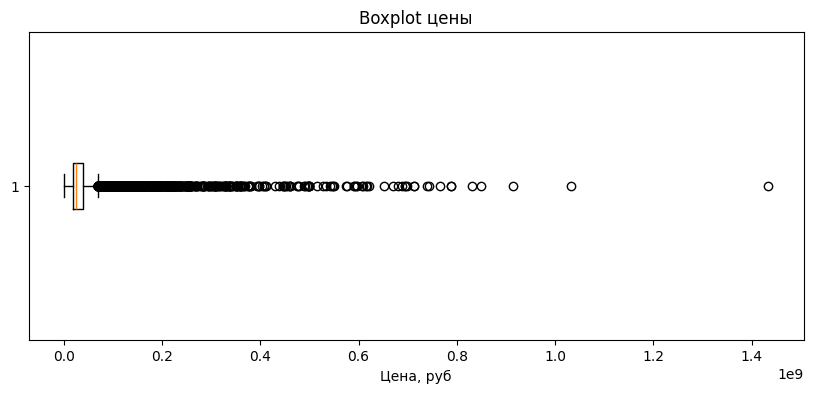

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

Явно есть сильные выбросы. Цена квартиры не может быть меньше 100 к рублей — значения ниже это ошибки парсинга. За верхний порог возьмём 95-й квантиль, чтобы убрать единичные сверхдорогие объекты и сохранить максимум данных

Осталось объектов 9732 , удалено 514


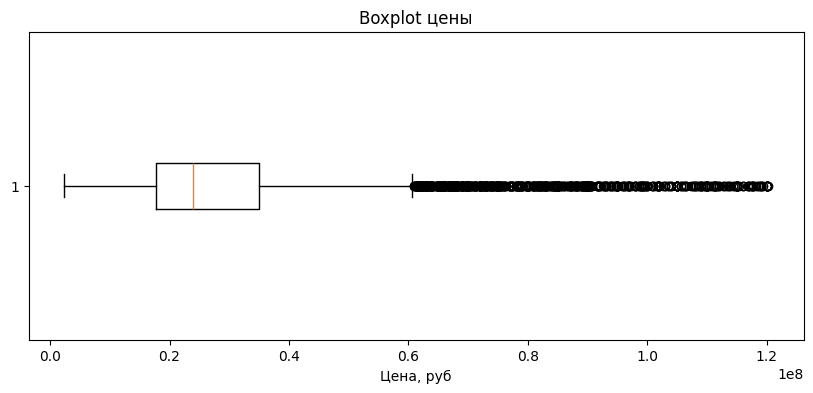

In [ ]:
lower = 100000
upper = df['Цена'].quantile(0.95)
n = len(df)
df_clean = df[(df['Цена'] >= 100000) & (df['Цена'] <= upper)]
print('Осталось объектов', len(df_clean), ', удалено', n-len(df_clean))

plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

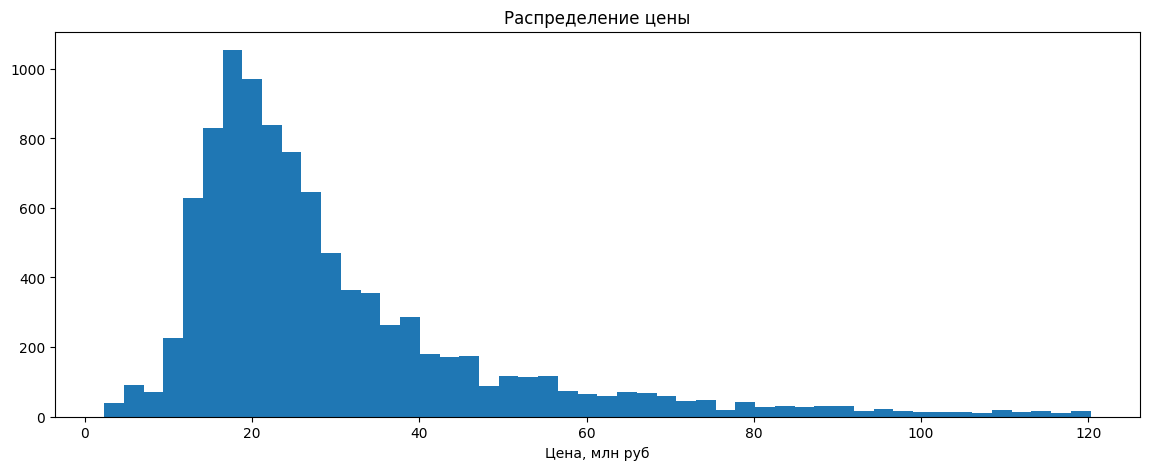

In [ ]:
plt.figure(figsize=(14, 5))
plt.hist(df_clean['Цена']/10**6, bins=50)
plt.title('Распределение цены')
plt.xlabel('Цена, млн руб')
plt.show()


Большинство квартир стоят до 50 млн рублей. Есть небольшое количество дорогих объектов, которые тянут хвост вправо, но это нормально для рынка недвижимости.

Теперь перейдем к анализу метрик. Рассмотрим признаки, которые имеют среднюю и сильную корреляцию с каким-то отличным от самих признаком

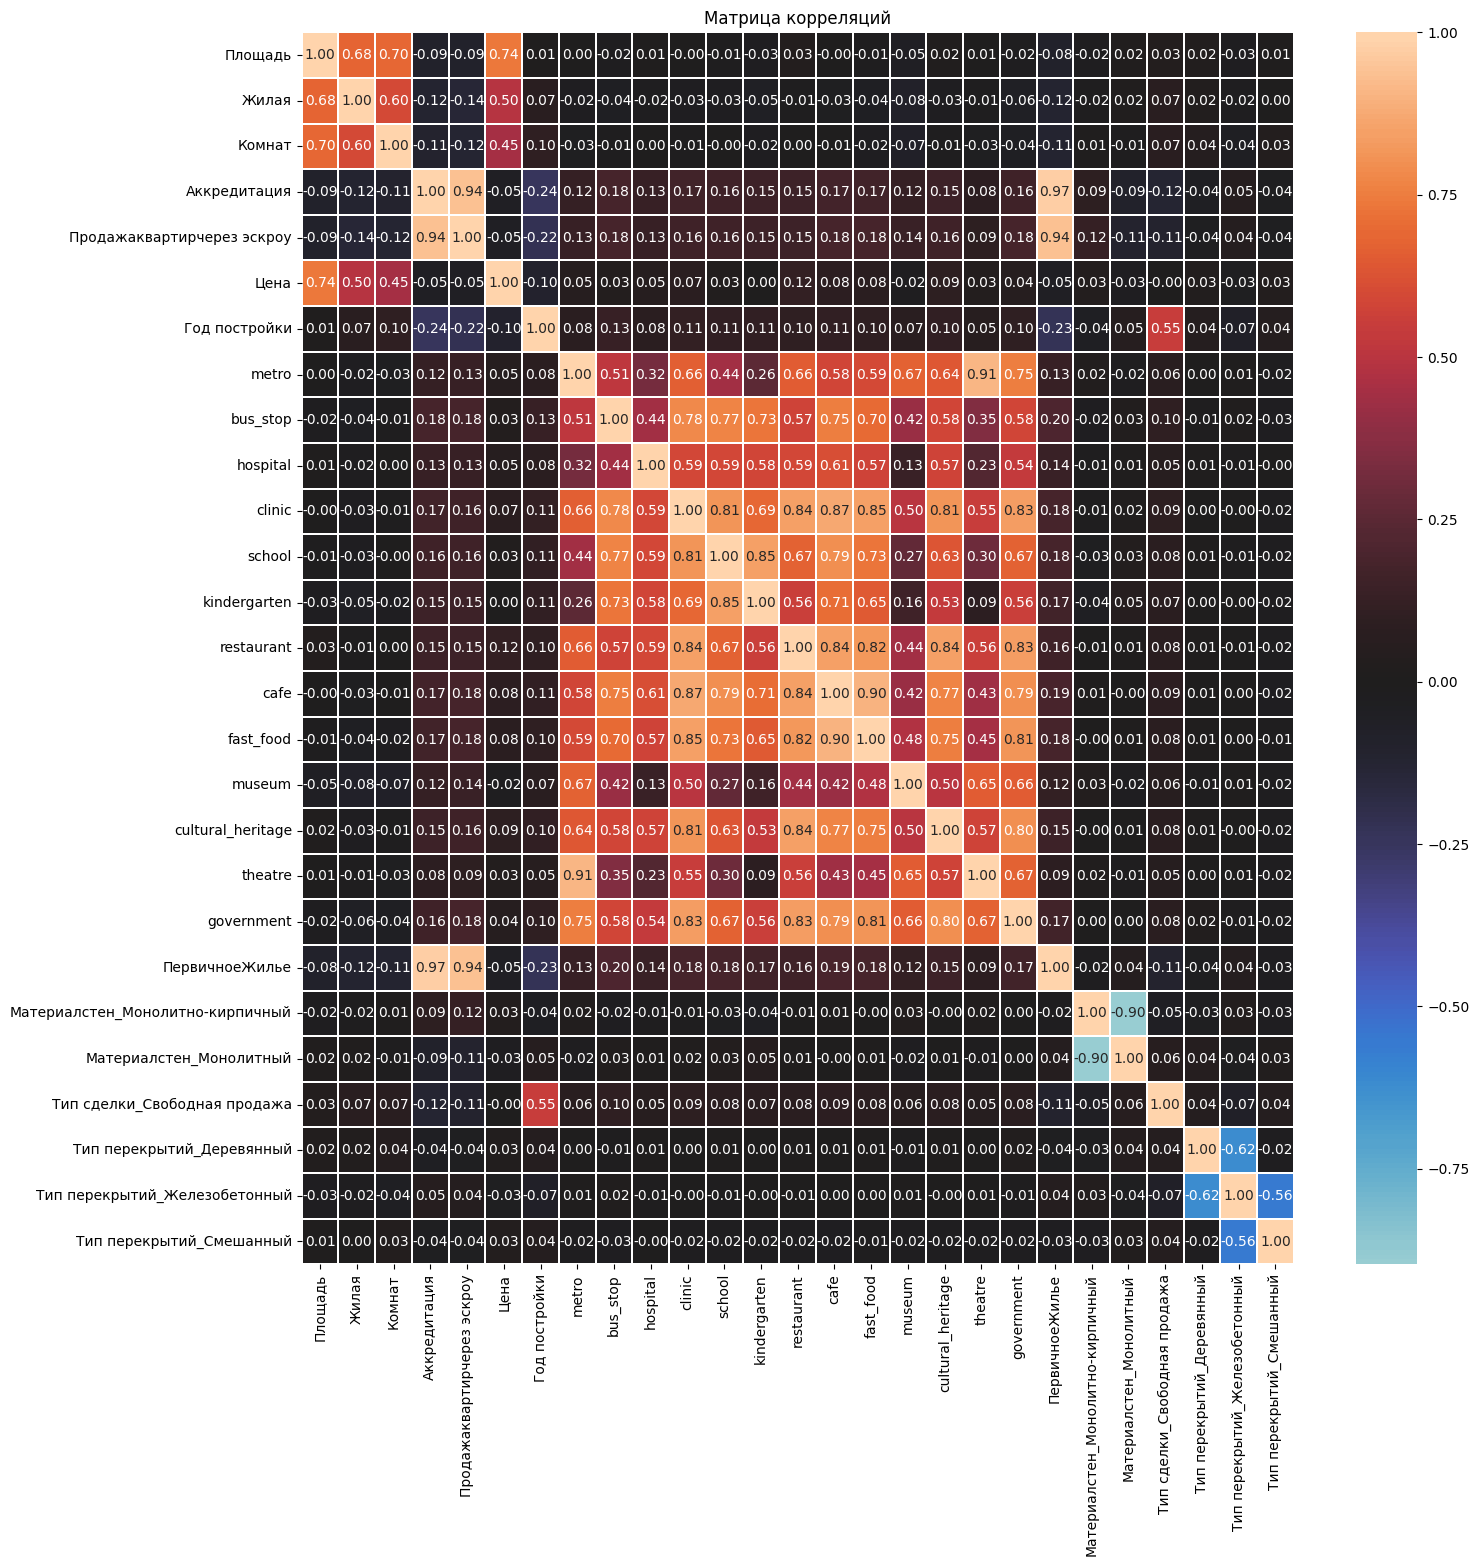

In [ ]:
#corr_matrix = df_clean.drop(columns=['Метро', 'АО', 'Строительнаяготовность']).corr()
corr_matrix = df_clean.drop(columns=['Метро']).corr()

useful_cols = corr_matrix[(corr_matrix.abs() > 0.5).sum() > 1].index

plt.figure(figsize=(16, 16))
sns.heatmap(
    corr_matrix.loc[useful_cols, useful_cols],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3
)
plt.title('Матрица корреляций')
plt.show()

Матрица корреляций показывает достаточно много признаков сильно связаны друг с другом.

На цену больше всего влияет площадь (0.72), жилая площадь (0.64) и количество комнат (0.50). В целом логично чем больше квартира, тем дороже.

Также видно что некоторые признаки почти полностью дублируют друг друга. Например, Аккредитация, Продажаквартирчерез эскроу, ПервичноеЖилье имеют корреляции 0.97–0.99, это один и тот же смысл. Из этой тройки можно оставить один признак , например ПервичноеЖилье как наиболее понятный, остальные два дропаем.

Материалстен_Монолитно-кирпичный и Материалстен_Монолитный (-0.93), но это два разных материала которые взаимно исключают друг друга, поэтому скорее оставляем.

In [ ]:
df = df.drop(columns=['Аккредитация', 'Продажаквартирчерез эскроу'])

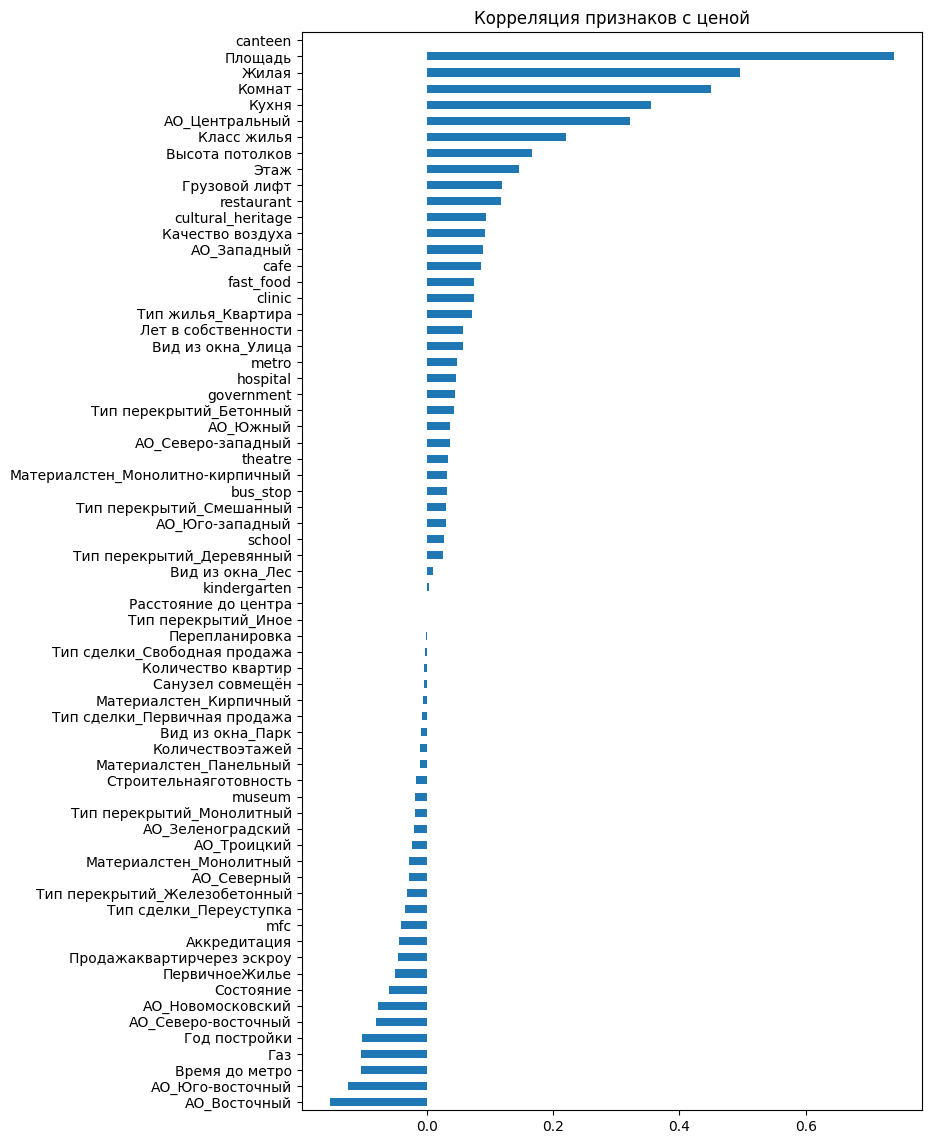

In [ ]:
corr_target = df_clean.drop(columns=['Метро']).corr()['Цена'].drop('Цена').sort_values()

plt.figure(figsize=(8, 14))
corr_target.plot(kind='barh')
plt.title('Корреляция признаков с ценой')
plt.show()

Если более детально посмотреть на корреляции с ценой — сильнее всего влияют площадные признаки Площадь, Жилая, Кухня, Комнат. Далее идут характеристики жилья Класс жилья и Качество воздуха. Чуть слабее — Высота потолков и Этаж. Всё остальное практически не коррелирует с ценой линейно.
Интересно что Газ и Время до метро уходят в минус. Вероятно газифицированные дома это старый фонд, а далеко от метро дешевле.

Связи с округом сейчас оставим без внимания, их мы проанализируем дальше

Гипотеза 1. Чем больше площадь - тем выше цена. Уже видно из матрицы (0.72), но интересно посмотреть есть ли линейная зависимость или она ломается на очень больших площадях.

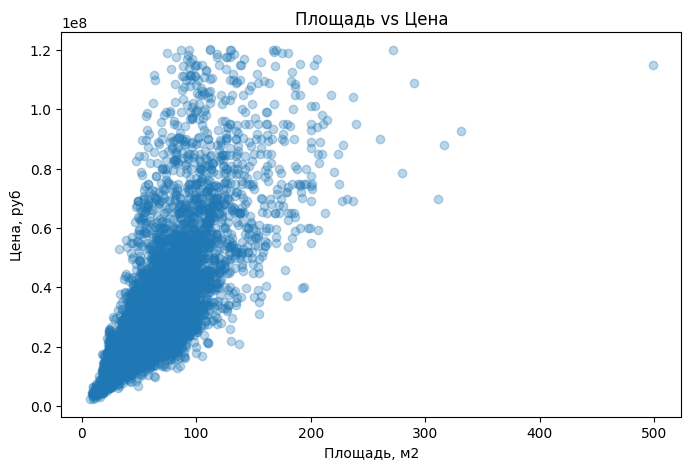

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Площадь'], df_clean['Цена'], alpha=0.3)
plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Площадь vs Цена')
plt.show()

Гипотеза 2. Первичное жильё дороже вторичного при одинаковой площади — новостройки продаются с наценкой за новизну и инфраструктуру.

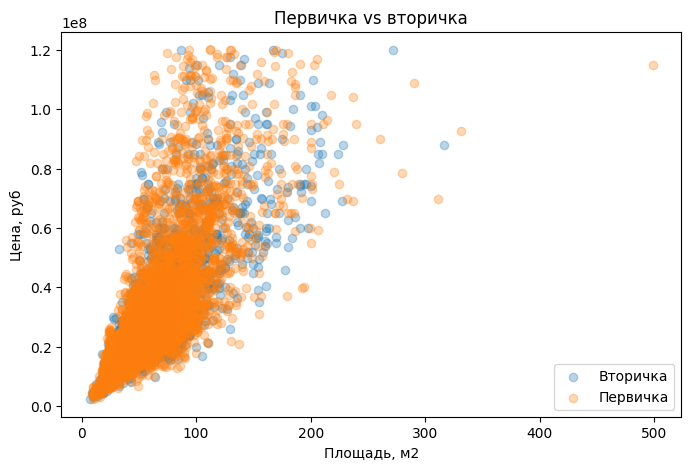

In [ ]:
plt.figure(figsize=(8, 5))
for val, label in [(0, 'Вторичка'), (1, 'Первичка')]:
    mask = df_clean['ПервичноеЖилье'] == val
    plt.scatter(df_clean[mask]['Площадь'], df_clean[mask]['Цена'], alpha=0.3, label=label)

plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Первичка vs вторичка')
plt.legend()
plt.show()

Гипотеза 3. Чем ближе к метро — тем дороже квартира. Время до метро показывает -0.09 с ценой, но это слабо — возможно эффект нелинейный и лучше виден на группах (до 5 минут, 5–15, 15+).

/tmp/ipykernel_31027/3669498395.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')


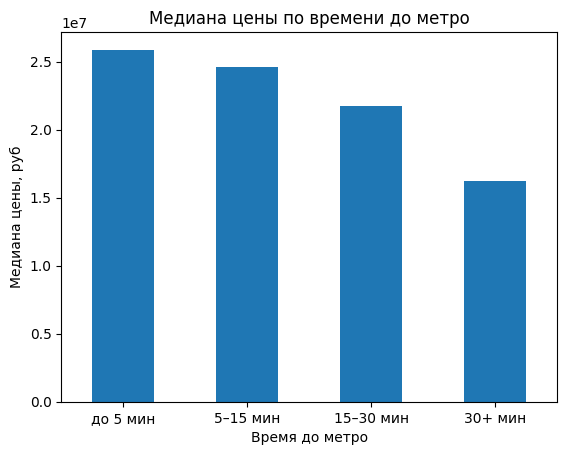

In [ ]:
df_clean['Метро_группа'] = pd.cut(
    df_clean['Время до метро'],
    bins=[0, 5, 15, 30, 100],
    labels=['до 5 мин', '5–15 мин', '15–30 мин', '30+ мин']
)

df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')
plt.xlabel('Время до метро')
plt.ylabel('Медиана цены, руб')
plt.title('Медиана цены по времени до метро')
plt.xticks(rotation=0)
plt.show()

В целом графики подтвердили визуально гипотезы. Площадь близко к линейному влияет на цену. Первичка и вторичка при одинаковой площади стоят примерно одинаково — да. Близость к метро влияет на цену чем дальше, тем дешевле - тоже подтвердилась

Теперь попробуем проанализировать влияние округа на некоторые ключевые параметры, как цена, площадь, кол-во комнат, время до метро, кол-во этажей и состояние квартиры

In [ ]:
columns = [
    'Цена',
    'Площадь',
    'Комнат',
    'Время до метро',
    'Количествоэтажей',
    'Состояние'
]

okrug_columns = [col for col in df_clean.columns if col.startswith('АО_')]

df_corr = df_clean[columns + okrug_columns].copy()

In [ ]:
corr_matrix = df_corr.corr()

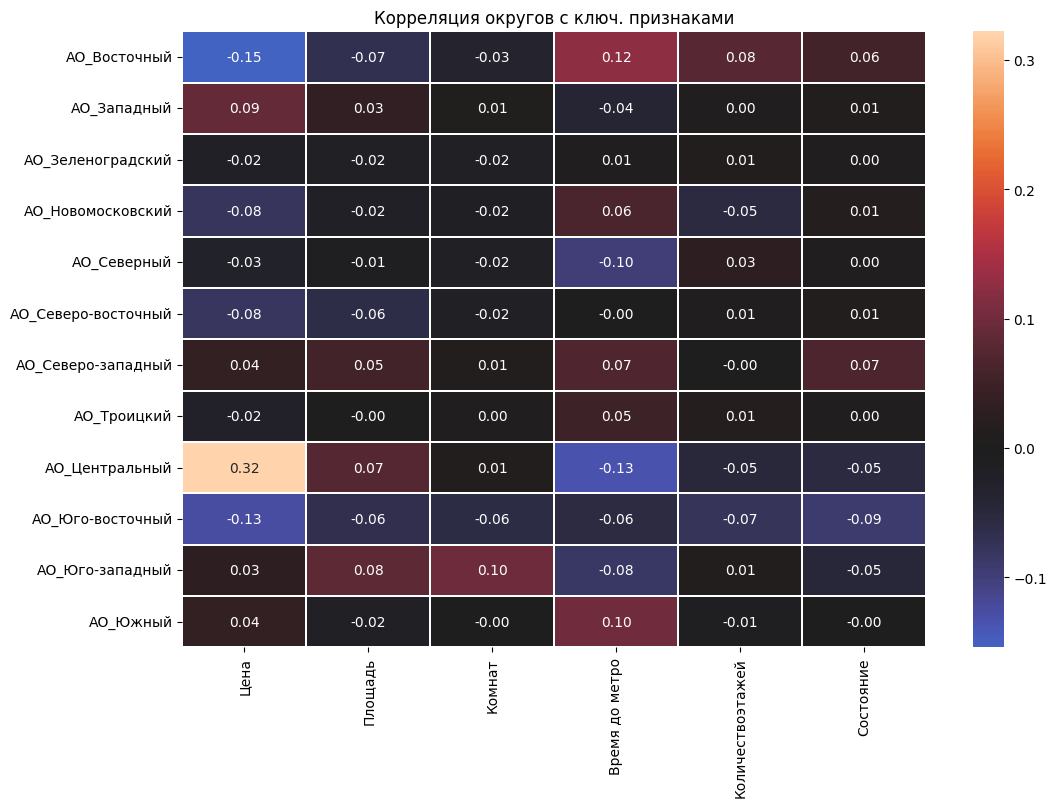

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix.loc[okrug_columns, columns],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3,
)

plt.title('Корреляция округов с ключ. признаками')
plt.show()


По этой корреляц. матрице можно сделать следующие выводы:

1. Заметно сильное влияние и округа цены только для объектов, у который округ - центральный (0.43)
Что удивительно, для Западного округа (который тоже считается дорогим) корреляция гораздо меньше (0.06)
А для восточного округа корреляция -(0.15), что значит, что этот округ дешевле среднего

2. Также в центральном округе корреляция с временом до метро (-0.16), в то время как в восточном - (0.12), т.е. в центральном округе метро в основном шаговой доступности, в то время как в восточом округе оно в среднем далеко от объектов

3. Состояние объектов в северо-западном округе в среднем лучше, чем в других районах. Скорее всего это связано с тем, что в последние 10 лет этот район активнее других застраивался и преобразовывался, поэтому состояние квартир там на текущий момент лучше, чем в других районах

4. Связь ключевых параметров и округа оказалась не особо существенной, большие корреляции не были замечены, из чего мы делаем вывод, что ключ. параметры объектов распределены более-менее равномерно по всем округам (кроме ЦАО)  

Теперь обратимся к переменной строительная готовность и попробуем проанализировать взаимосвязь (для новостроек) этого признака и цены

Проверим гипотезу: цена объекта и уровень его готовности - линейно зависимые величины (т.е. при увеличении уровня готовности объекта, не будет "резких" перепадов)

Построим график зависимости

<Figure size 800x500 with 0 Axes>

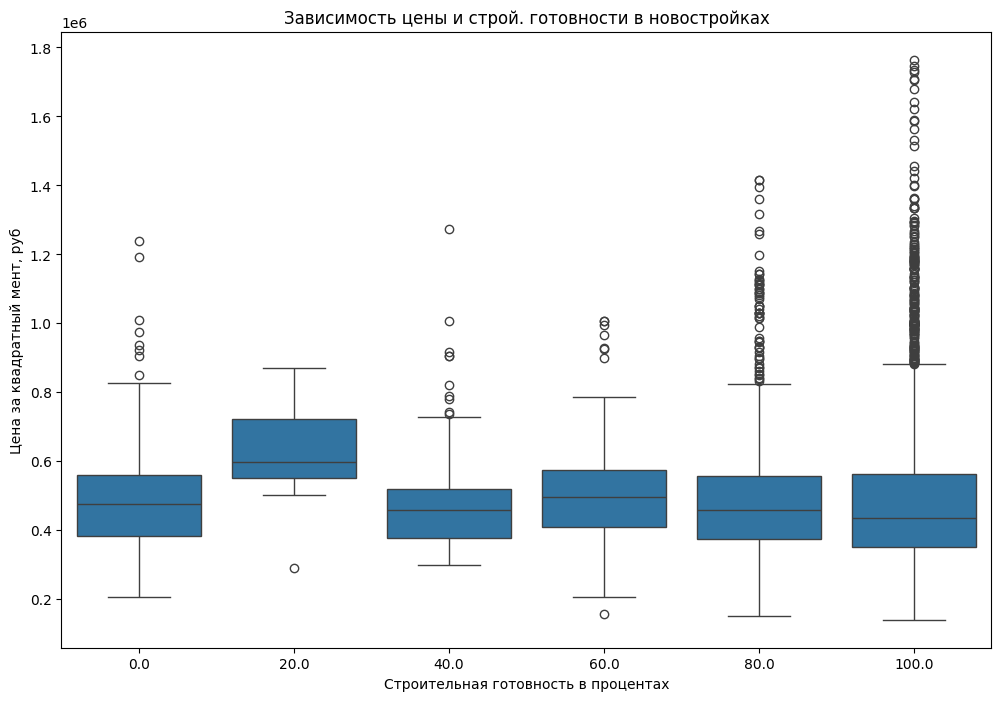

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 5))

tempMask = (df_clean['Строительнаяготовность'].notna()) & (df_clean['ПервичноеЖилье'] == 1)
plot_df = df_clean.loc[tempMask, ['Строительнаяготовность', 'Цена', 'Площадь']].copy()
plot_df['Цена_за_м^2'] = plot_df['Цена'] / plot_df['Площадь']
plot_df['Готовность_группа'] = (plot_df['Строительнаяготовность']//20)*20

plt.figure(figsize=(12, 8))
sns.boxplot(data=plot_df, x='Готовность_группа', y='Цена_за_м^2')

plt.xlabel('Строительная готовность в процентах')
plt.ylabel('Цена за квадратный мент, руб')
plt.title('Зависимость цены и строй. готовности в новостройках')
plt.show()

Из графика становится ясно, что на каждом уровне готовности наблюдается широкий разброс цен, и нельзя подтвердить гипотезу о линейном возрастании цены квартиры (за квадратный метр)

Также заметим, что чем больше строй. готовность, тем больше "выбросов", что вероятней всего связано с тем, что на ранних этапах готовности дорогие лоты не продаются в открытую, а презентуются на закрытых показах

Таким образом, делаем вывод, что цена на новостройки не определяется уровнем готовности, а определяется другими параметрами (площадь/расположение/цена и пр.)

Рассмотрим первую гипотезу на этот счет. Она заключается в том, что состояние квартиры влияет на ее цену по-разному в зависимости от сегмента жилья. То есть хороший ремонт сильнее повышает стоимость 1–2-комнатных квартир, особенно на вторичном рынке, тогда как для более крупных объектов или части новостроек этот эффект может быть слабее.


In [ ]:
h1 = df_clean[['Цена', 'Площадь', 'Комнат', 'Состояние', 'ПервичноеЖилье']].copy()
h1 = h1[(h1['Цена'] > 0) & (h1['Площадь'] > 0) & (h1['Комнат'] > 0)].dropna()

h1['цена_м2'] = h1['Цена'] / h1['Площадь']
h1 = h1[(h1['цена_м2'] >= h1['цена_м2'].quantile(0.01)) & (h1['цена_м2'] <= h1['цена_м2'].quantile(0.99))]

h1['комнаты'] = '3к+'
h1.loc[h1['Комнат'] == 1, 'комнаты'] = '1к'
h1.loc[h1['Комнат'] == 2, 'комнаты'] = '2к'

h1['тип'] = h1['ПервичноеЖилье'].map({0: 'вторичка', 1: 'первичка'})

result = h1.groupby(['тип', 'комнаты', 'Состояние'])['цена_м2'].median().reset_index()
result.columns = ['тип', 'комнаты', 'состояние', 'медиана цена/м2']
print(result)

         тип комнаты  состояние  медиана цена/м2
0   вторичка      1к          1    417142.857143
1   вторичка      1к          2    453225.753389
2   вторичка      1к          3    396087.010682
3   вторичка      1к          4    467092.851753
4   вторичка      1к          5    448070.287625
5   вторичка      2к          2    450635.061291
6   вторичка      2к          3    413966.373043
7   вторичка      2к          4    445502.293104
8   вторичка      2к          5    412946.428571
9   вторичка     3к+          2    430809.399478
10  вторичка     3к+          3    365853.658537
11  вторичка     3к+          4    528634.361233
12  вторичка     3к+          5    400000.000000
13  первичка      1к          2    490455.000000
14  первичка      1к          3    455775.000000
15  первичка      1к          4    480315.000000
16  первичка      1к          5    454400.000000
17  первичка      2к          2    429693.597341
18  первичка      2к          3    399006.889764
19  первичка      2к

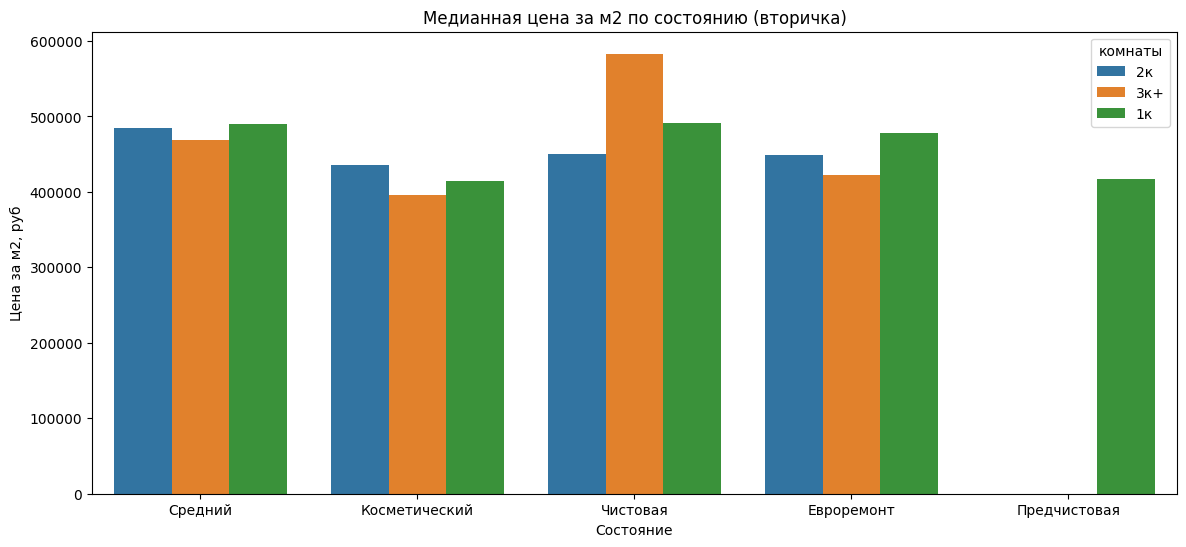

In [ ]:
state_names = {0: 'Без ремонта', 1: 'Предчистовая', 2: 'Средний', 3: 'Косметический', 4: 'Чистовая', 5: 'Евроремонт'}
#remont_map = {'Без ремонта': 0, 'Предчистовая': 1, 'Средний': 2, 'Косметический': 3, 'Чистовая': 4, 'Евроремонт': 5} - вспоминаем начало)
h1['состояние_текст'] = h1['Состояние'].map(state_names)
state_order = list(state_names.values())

plt.figure(figsize=(14, 6))
sns.barplot(
    data=h1[h1['тип'] == 'вторичка'],
    x='состояние_текст',
    y='цена_м2',
    hue='комнаты',
    errorbar=None #без него есть линии вертикальные появляются
)
plt.title('Медианная цена за м2 по состоянию (вторичка)')
plt.xlabel('Состояние')
plt.ylabel('Цена за м2, руб')
plt.show()

Чистовая отделка даёт заметную премию для 1к квартир, примерно +30% к медиане относительно среднего состояния. Для 2к и 3к+ эффект слабее. Гипотеза частично подтвердилась

Вторая гипотеза заключается в том, что для квартир с одинаковым числом комнат и сопоставимой общей площадью цена зависит не только от размера квартиры, но и от эффективности планировки. Предполагается, что квартиры с более удобным распределением площади, например с большей площадью на комнату, могут стоить дороже за квадратный метр.

In [ ]:
h2 = df_clean[['Цена', 'Площадь', 'Комнат']].copy()

h2 = h2.dropna()
h2 = h2[(h2['Цена'] > 0) & (h2['Площадь'] > 0) & (h2['Комнат'] > 0)]

h2['Цена_за_м2'] = h2['Цена'] / h2['Площадь']
h2['Площадь_на_комнату'] = h2['Площадь'] / h2['Комнат']

In [ ]:
h2['комнаты'] = '3к+'
h2.loc[h2['Комнат'] == 1, 'комнаты'] = '1к'
h2.loc[h2['Комнат'] == 2, 'комнаты'] = '2к'


In [ ]:
h2['Группа_площади'] = pd.cut(
    h2['Площадь'],
    bins=[0, 40, 55, 70, 90, 130, 300],
    labels=['до 40', '40-55', '55-70', '70-90', '90-130', '130+']
)

In [ ]:
def safe_qcut(x):
    if x.notna().sum() < 20 or x.nunique() < 4:
        return pd.Series(np.nan, index=x.index)
    return pd.qcut(x, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

h2['квантиль'] = h2.groupby(['комнаты', 'Группа_площади'])['Площадь_на_комнату'].transform(safe_qcut)

result = h2.groupby(['комнаты', 'Группа_площади', 'квантиль'])['Цена_за_м2'].median().reset_index()
result = result[result['Цена_за_м2'].notna()]
result

/tmp/ipykernel_31027/54686218.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h2['квантиль'] = h2.groupby(['комнаты', 'Группа_площади'])['Площадь_на_комнату'].transform(safe_qcut)
/tmp/ipykernel_31027/54686218.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = h2.groupby(['комнаты', 'Группа_площади', 'квантиль'])['Цена_за_м2'].median().reset_index()


,комнаты,Группа_площади,квантиль,Цена_за_м2
0,1к,до 40,Q1,4.809430e+05
1,1к,до 40,Q2,4.587085e+05
2,1к,до 40,Q3,4.598100e+05
3,1к,до 40,Q4,4.566137e+05
4,1к,40-55,Q1,4.727277e+05
5,1к,40-55,Q2,4.846284e+05
6,1к,40-55,Q3,5.083281e+05
7,1к,40-55,Q4,5.676768e+05
8,1к,55-70,Q1,6.668551e+05
9,1к,55-70,Q2,7.107882e+05


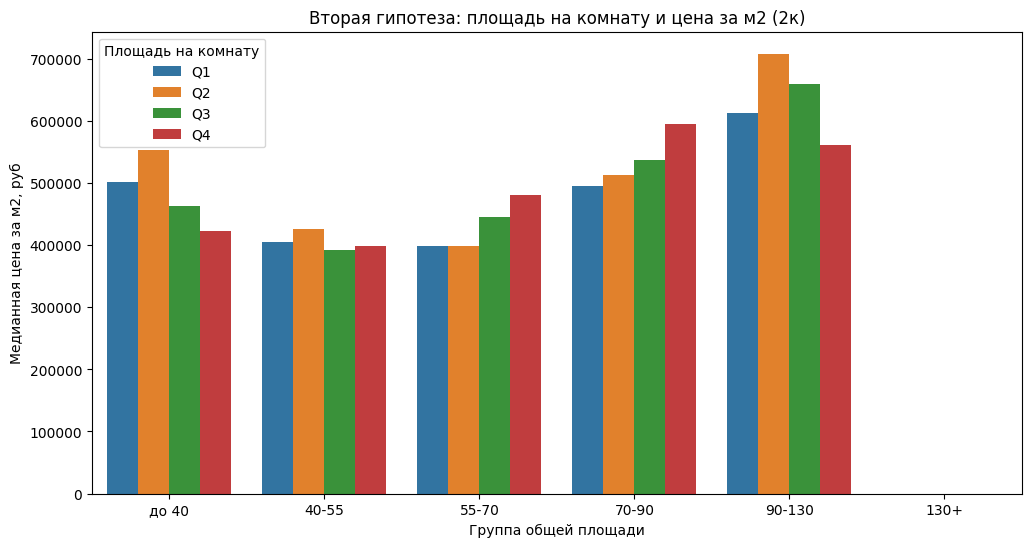

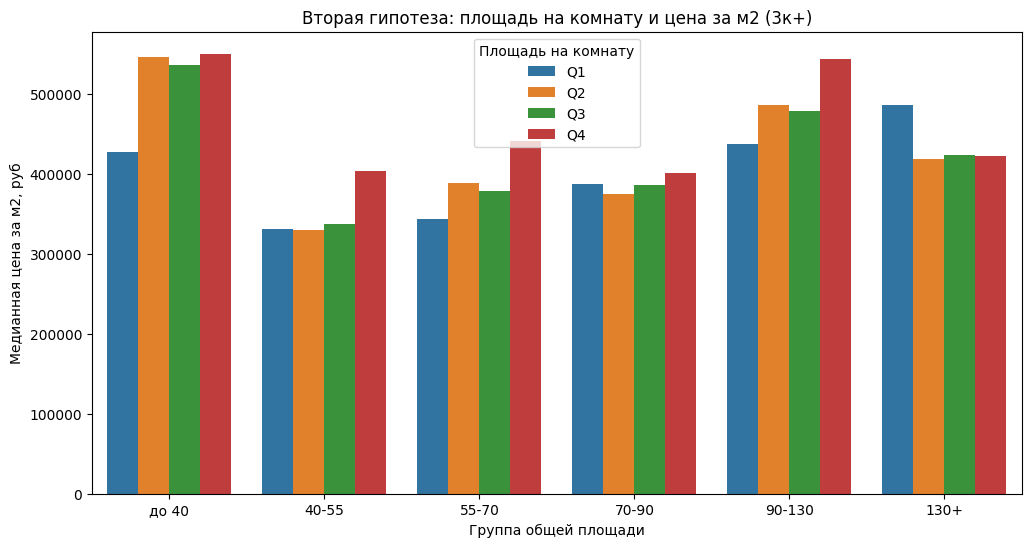

In [ ]:
for seg in ['2к', '3к+']:
    temp = result[result['комнаты'] == seg]

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=temp,
        x='Группа_площади',
        y='Цена_за_м2',
        hue='квантиль'
    )

    plt.title(f'Вторая гипотеза: площадь на комнату и цена за м2 ({seg})')
    plt.xlabel('Группа общей площади')
    plt.ylabel('Медианная цена за м2, руб')
    plt.legend(title='Площадь на комнату')
    plt.show()

Гипотеза подтвердилась частично. Для 2к квартир площадью 55–90 м2 и 3к+ квартир от 90 м2 чётко видно - чем больше площадь на комнату, тем выше цена за метр. Для небольших квартир до 55 м такой зависимости в явном виде нет

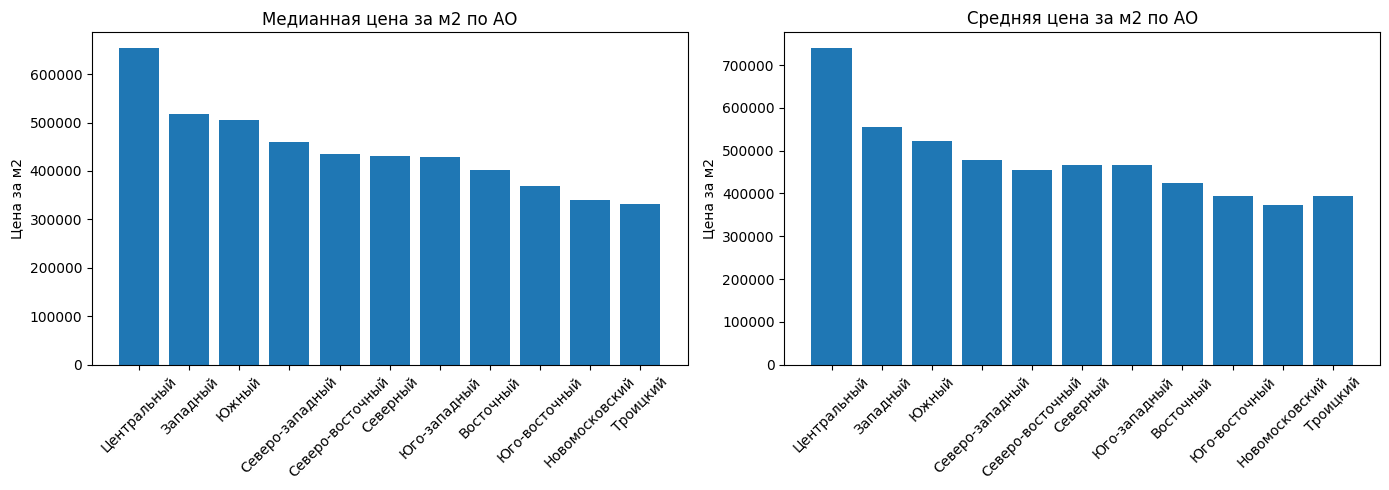

In [ ]:
data = df_clean.copy()
ao_cols = [col for col in data.columns if col.startswith('АО_')]
data['АО'] = data[ao_cols].idxmax(axis=1).str.replace('АО_', '')

data['цена_м2'] = data['Цена'] / data['Площадь']
ao_stat = data.groupby('АО')['цена_м2'].agg(['median', 'mean', 'count']).reset_index()
ao_stat = ao_stat[ao_stat['count'] >= 20].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ao_stat['АО'], ao_stat['median'])
axes[0].set_title('Медианная цена за м2 по АО')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Цена за м2')

axes[1].bar(ao_stat['АО'], ao_stat['mean'])
axes[1].set_title('Средняя цена за м2 по АО')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Цена за м2')

plt.tight_layout()
plt.show()

Центральный округ ожидаемо лидирует по цене. Восточный и Юго-восточный —- самые дешевые. Разрыв между дорогими и дешёвыми округами примерно двукратный.

/tmp/ipykernel_31027/3768494860.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  air_stat = temp.groupby('группа_воздуха')['цена_м2'].agg(['median', 'mean', 'count']).reset_index()


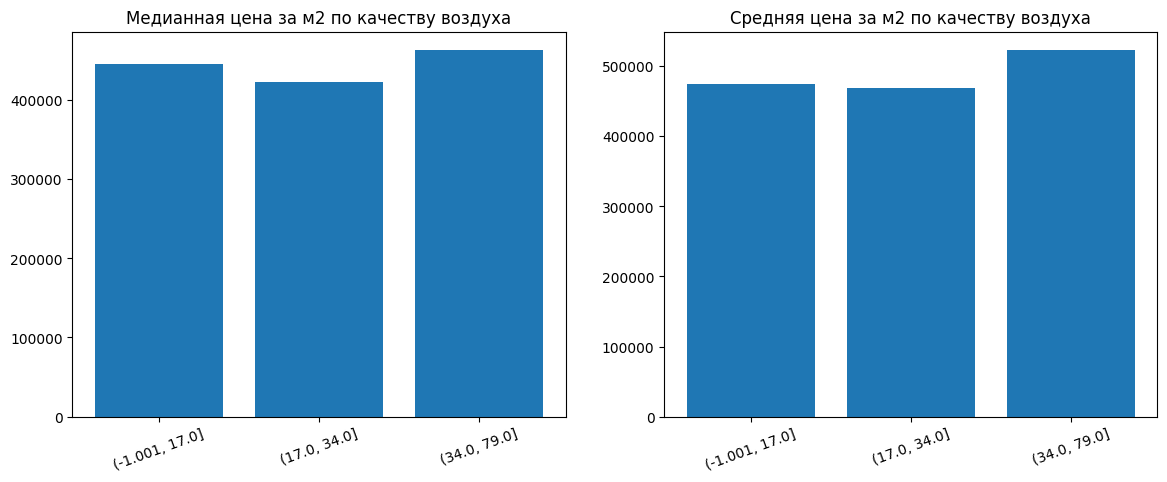

In [ ]:
temp = data.copy()
temp['Качество воздуха'] = pd.to_numeric(temp['Качество воздуха'], errors='coerce')
temp = temp[temp['Качество воздуха'] != 0]
temp = temp.dropna(subset=['Качество воздуха', 'цена_м2'])

temp['группа_воздуха'] = pd.qcut(temp['Качество воздуха'], q=4, duplicates='drop')

air_stat = temp.groupby('группа_воздуха')['цена_м2'].agg(['median', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['median', 'mean'], ['Медианная', 'Средняя']):
    ax.bar(air_stat['группа_воздуха'].astype(str), air_stat[col])
    ax.set_title(f'{title} цена за м2 по качеству воздуха')
    ax.tick_params(axis='x', rotation=20)

plt.show()

Четкой зависимости цены от качества воздуха нет, разброс между группами минимальный. Однако более качественный воздух и более богатых все же

# 3.Создание модели для предсказания стоимости жилья

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

In [ ]:
df_imp = df_clean.copy()

In [ ]:
X = df_imp.drop(columns=['Цена'])
y = np.log1p(df_imp['Цена'])

In [ ]:
correlations = X.select_dtypes(include='number').corrwith(df_imp['Цена']).abs()
low_corr = correlations[correlations < 0.01].index.tolist()

print('Удаляем', low_corr)
X = X.drop(columns=low_corr, errors='ignore')
print('Признаков осталось', X.shape[1])

Удаляем ['Санузел совмещён', 'Перепланировка', 'Количество квартир', 'kindergarten', 'Расстояние до центра', 'Вид из окна_Лес', 'Вид из окна_Парк', 'Материалстен_Кирпичный', 'Тип сделки_Первичная продажа', 'Тип сделки_Свободная продажа', 'Тип перекрытий_Иное']
Признаков осталось 58


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype(str)

print('Категориальных:', cat_cols)
print('Числовых:', X.shape[1] - len(cat_cols))

Категориальных: ['Метро', 'Метро_группа']
Числовых: 56


In [ ]:
X = pd.get_dummies(X, columns=['Метро_группа'], dtype=int)
#П Метро_группа кодируем OHE, так как для модели нужны числа
# "Метро" не берём, так как слишком много уникальных значений, зашумит модель
X = X.drop(columns=['Метро'])

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train.shape, X_valid.shape, X_test.shape

((5839, 60), (1946, 60), (1947, 60))

In [ ]:
cat_features_idx = [X_train.columns.get_loc(col) for col in cat_cols if col in X_train.columns]

param_grid = {
    'iterations':          [2000, 3000, 5000],
    'depth':               [5, 6, 7, 8],
    'learning_rate':       [0.01, 0.03, 0.05],
    'l2_leaf_reg':         [1, 3, 5, 10],
    'min_data_in_leaf':    [10, 20, 50],
    'bagging_temperature': [0.0, 0.5, 1.0],
}

sampler = list(ParameterSampler(param_grid, n_iter=30, random_state=42))
results = []

for i, params in enumerate(sampler):
    model = CatBoostRegressor(**params, loss_function='RMSE', eval_metric='RMSE',
                              early_stopping_rounds=50, verbose=0, random_seed=42)
    model.fit(X_train, y_train, cat_features=cat_features_idx,
              eval_set=(X_valid, y_valid), use_best_model=True)

    mape = mean_absolute_percentage_error(np.expm1(y_valid), np.expm1(model.predict(X_valid)))
    results.append({**params, 'mape_valid': round(mape * 100, 2)})
    print(f"[{i+1}/30] MAPE: {round(mape*100,2)}%",  params)

NameError: name 'ParameterSampler' is not defined

In [ ]:
results_df = pd.DataFrame(results).sort_values('mape_valid').reset_index(drop=True)
results_df.head()

In [ ]:
best = results_df.iloc[0].drop('mape_valid').to_dict()
for key in ['iterations', 'depth', 'min_data_in_leaf']:
    best[key] = int(best[key])

final_model = CatBoostRegressor(**best, loss_function='RMSE', eval_metric='RMSE', random_seed=42)

final_model.fit(X_train, y_train, cat_features=cat_features_idx,
           eval_set=(X_valid, y_valid),verbose=200, use_best_model=True)

pred_test = np.expm1(final_model.predict(X_test))
mape_test = mean_absolute_percentage_error(np.expm1(y_test), pred_test)
print('Тестовый MAPE:', round(mape_test * 100, 2), '%')

In [ ]:
importance = pd.DataFrame({
    'Фактор': X_train.columns,
    'Важность': final_model.get_feature_importance()
}).sort_values('Важность', ascending=False).reset_index(drop=True)

importance

In [ ]:
weak = importance[importance['Важность'] < 0.1]['Фактор'].tolist()

In [ ]:
X_train2 = X_train.drop(columns=weak)
X_valid2 = X_valid.drop(columns=weak)
X_test2  = X_test.drop(columns=weak)

cat_features_idx2 = [X_train2.columns.get_loc(col) for col in cat_cols if col in X_train2.columns]

model2 = CatBoostRegressor(**best, loss_function='RMSE', eval_metric='RMSE',
                           verbose=200, random_seed=42)

model2.fit(X_train2, y_train, cat_features=cat_features_idx2,
           eval_set=(X_valid2, y_valid), use_best_model=True)

pred2 = np.expm1(model2.predict(X_test2))
mape2 = mean_absolute_percentage_error(np.expm1(y_test), pred2)
print('MAPE:', round(mape2 * 100, 2), '%')

Улучшения не произошло. Для сравнения. Попробуем обучить модель линейной регрессии

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterSampler

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
x = 1
results_lr = []
for alpha in param_grid['alpha']:
    model_lr = Ridge(alpha=alpha)
    model_lr.fit(X_train, y_train)
    mape = mean_absolute_percentage_error(np.expm1(y_valid), np.expm1(model_lr.predict(X_valid)))
    x = min(mape, x)
    print(alpha, mape)


print(x)

Сильно хуже результаты чем у Catboost